# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Zacky Maulana]
- **Email:** [bossrete@gmail.com]
- **ID Dicoding:** [zckyymmm912]

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang memiliki tingkat penjualan (volume) tertinggi, dan kategori apa yang menyumbang pendapatan (*revenue*) terbesar bagi perusahaan?
- **Pertanyaan 2:** Bagaimana demografi persebaran pelanggan berdasarkan wilayah, dan kota mana yang menjadi basis pelanggan terbanyak?

## Import Semua Packages/Library yang Digunakan

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [11]:
import pandas as pd

# Memuat semua 9 tabel dari dataset E-Commerce
customers_df = pd.read_csv("data/E-Commerce Public Dataset/customers_dataset.csv")
geolocation_df = pd.read_csv("data/E-Commerce Public Dataset/geolocation_dataset.csv")
order_items_df = pd.read_csv("data/E-Commerce Public Dataset/order_items_dataset.csv")
order_payments_df = pd.read_csv("data/E-Commerce Public Dataset/order_payments_dataset.csv")
order_reviews_df = pd.read_csv("data/E-Commerce Public Dataset/order_reviews_dataset.csv")
orders_df = pd.read_csv("data/E-Commerce Public Dataset/orders_dataset.csv")
category_translation_df = pd.read_csv("data/E-Commerce Public Dataset/product_category_name_translation.csv")
products_df = pd.read_csv("data/E-Commerce Public Dataset/products_dataset.csv")
sellers_df = pd.read_csv("data/E-Commerce Public Dataset/sellers_dataset.csv")

print("9 file CSV berhasil dimuat semuanya")

9 file CSV berhasil dimuat semuanya


**Insight:**
- Proses pengumpulan data (Gathering Data) telah berhasil dilakukan dengan memuat 9 file mentah berformat CSV ke dalam bentuk DataFrame menggunakan library pandas.

- Data yang dikumpulkan sudah komprehensif untuk menjawab pertanyaan bisnis, mencakup aspek operasional e-commerce seperti data pelanggan, riwayat pesanan, detail produk, pembayaran, hingga geolokasi.

- Seluruh dataset kini telah terhubung ke dalam ruang kerja (notebook) dan siap untuk dievaluasi struktur serta kualitasnya pada tahapan selanjutnya (Assessing Data).

### Assessing Data

In [12]:
# Membuat list dataframe beserta namanya
datasets = {
    "Customers": customers_df,
    "Geolocation": geolocation_df,
    "Order Items": order_items_df,
    "Order Payments": order_payments_df,
    "Order Reviews": order_reviews_df,
    "Orders": orders_df,
    "Category Translation": category_translation_df,
    "Products": products_df,
    "Sellers": sellers_df
}

# Looping untuk mengecek duplikat dan missing values
for name, df in datasets.items():
    print(f"--- Info Data: {name} ---")
    print(f"Jumlah baris: {df.shape[0]}")
    print(f"Jumlah duplikat: {df.duplicated().sum()}")
    print(f"Jumlah Missing Values:\n{df.isnull().sum()}\n")

--- Info Data: Customers ---
Jumlah baris: 99441
Jumlah duplikat: 0
Jumlah Missing Values:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

--- Info Data: Geolocation ---
Jumlah baris: 1000163
Jumlah duplikat: 261831
Jumlah Missing Values:
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

--- Info Data: Order Items ---
Jumlah baris: 112650
Jumlah duplikat: 0
Jumlah Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

--- Info Data: Order Payments ---
Jumlah baris: 103886
Jumlah duplikat: 0
Jumlah Missing Values:
order_id                0
payment_sequential      0
payment_type            0
payment_

**Insight:**
- Proses penilaian data (Assessing Data) telah dilakukan terhadap 9 tabel utama untuk mengidentifikasi anomali seperti inkonsistensi tipe data, nilai yang hilang (missing values), serta data duplikat.

- Berdasarkan hasil pengecekan, sebagian besar tabel memiliki integritas data yang baik dengan nol duplikasi, kecuali pada tabel geolocation_dataset yang memiliki jumlah duplikat signifikan, kemungkinan karena banyaknya transaksi yang terjadi pada kode pos (zip code) yang sama.

- Ditemukan missing values pada beberapa tabel yang bersifat situasional dan logis. Misalnya, pada tabel orders_dataset, nilai kosong pada tanggal pengiriman kemungkinan merepresentasikan pesanan yang dibatalkan atau belum diproses. Pada tabel order_reviews_dataset, nilai kosong pada komentar menandakan pelanggan hanya memberikan rating bintang tanpa ulasan teks.

- Tabel products_dataset memiliki sedikit missing values pada kategori dan dimensi fisik produk, yang perlu diatasi (misalnya dengan imputasi 'unknown') agar tidak mengganggu proses penggabungan data pada tahap selanjutnya.

### Cleaning Data

In [13]:
# 1. Membersihkan tabel orders_df: Mengubah tipe data teks menjadi datetime
datetime_columns = [
    "order_purchase_timestamp", 
    "order_approved_at", 
    "order_delivered_carrier_date", 
    "order_delivered_customer_date", 
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# 2. Membersihkan tabel geolocation_df: Menghapus duplikat yang tidak perlu
geolocation_df.drop_duplicates(inplace=True)

# 3. Membersihkan tabel products_df: Mengisi kategori yang kosong dengan 'unknown'
products_df.fillna({'product_category_name': 'unknown'}, inplace=True)

# Memeriksa kembali hasil pembersihan
print("--- Hasil Setelah Cleaning ---")
print(f"Sisa duplikat di Geolocation: {geolocation_df.duplicated().sum()}")
print(f"Sisa missing value di Kategori Produk: {products_df['product_category_name'].isnull().sum()}")
print("\nTipe data waktu di orders_df saat ini:")
print(orders_df[datetime_columns].dtypes)

--- Hasil Setelah Cleaning ---
Sisa duplikat di Geolocation: 0
Sisa missing value di Kategori Produk: 0

Tipe data waktu di orders_df saat ini:
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


**Insight:**
- Proses pembersihan data (Cleaning Data) telah dilakukan dengan pendekatan konservatif untuk menjaga integritas informasi transaksi.

- Tipe data pada kolom-kolom tanggal di tabel orders_dataset telah dikonversi menjadi format datetime untuk memfasilitasi analisis berbasis waktu dan perhitungan metrik seperti Recency pada RFM Analysis.

- baris duplikat pada geolocation_dataset telah dihapus. Hal ini dilakukan untuk mengoptimalkan kinerja pemrosesan data spasial tanpa menghilangkan keunikan titik koordinat tiap wilayah.

-  Missing values pada kolom product_category_name di products_dataset diimputasi dengan label 'unknown' untuk mencegah hilangnya baris data berharga saat dilakukan penggabungan (merging) tabel. Missing values pada tabel riwayat ulasan dan waktu pengiriman sengaja dipertahankan karena secara logis merepresentasikan kondisi dunia nyata (misal: pesanan dibatalkan atau pengguna tidak menuliskan teks ulasan).

## Exploratory Data Analysis (EDA)

### Explore ...

In [14]:
# 1. Menggabungkan order_items dengan orders
orders_items_merged = pd.merge(
    left=order_items_df,
    right=orders_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

# 2. Menggabungkan hasil di atas dengan products
orders_products_merged = pd.merge(
    left=orders_items_merged,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# 3. Menggabungkan dengan terjemahan kategori (agar namanya pakai bahasa Inggris)
all_df = pd.merge(
    left=orders_products_merged,
    right=category_translation_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)

# Jika ada kategori bahasa Inggris yang kosong, kita isi dengan nama aslinya
all_df.fillna({'product_category_name_english': all_df['product_category_name']}, inplace=True)

# --- MULAI EKSPLORASI ---

# A. Kategori Produk Paling Laris (Berdasarkan jumlah transaksi)
top_products_sales = all_df.groupby('product_category_name_english').order_id.nunique().sort_values(ascending=False).head(5)
print("--- Top 5 Kategori Produk Paling Laris ---")
print(top_products_sales)

# B. Kategori Produk dengan Revenue Tertinggi (Berdasarkan total harga)
top_products_revenue = all_df.groupby('product_category_name_english').price.sum().sort_values(ascending=False).head(5)
print("\n--- Top 5 Kategori Produk dengan Revenue Tertinggi ---")
print(top_products_revenue)

# C. Kota dengan Pelanggan Terbanyak
top_cities = customers_df.groupby('customer_city').customer_id.nunique().sort_values(ascending=False).head(5)
print("\n--- Top 5 Kota dengan Pelanggan Terbanyak ---")
print(top_cities)

--- Top 5 Kategori Produk Paling Laris ---
product_category_name_english
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
Name: order_id, dtype: int64

--- Top 5 Kategori Produk dengan Revenue Tertinggi ---
product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
Name: price, dtype: float64

--- Top 5 Kota dengan Pelanggan Terbanyak ---
customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
Name: customer_id, dtype: int64


**Insight:**
- Proses Eksplorasi Data (EDA) diawali dengan melakukan left merge pada tabel order_items, orders, products, dan category_translation untuk membentuk satu entitas data terpusat (all_df) yang menghubungkan informasi transaksi dengan detail produk.

- Berdasarkan analisis performa produk, ditemukan bahwa kategori tertentu (seperti bed_bath_table dan health_beauty) secara konsisten memimpin, baik dalam hal volume jumlah pesanan (sales frequency) maupun total pendapatan (revenue). Hal ini menunjukkan tingginya permintaan pasar pada sektor kebutuhan rumah tangga dan perawatan diri.

- Eksplorasi demografi dari customers_dataset menunjukkan pemusatan pelanggan yang sangat tinggi di kota Sao Paulo. Informasi ini krusial untuk nantinya divisualisasikan menggunakan Geospatial Analysis sebagai landasan strategi efisiensi logistik atau penargetan kampanye pemasaran di masa depan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

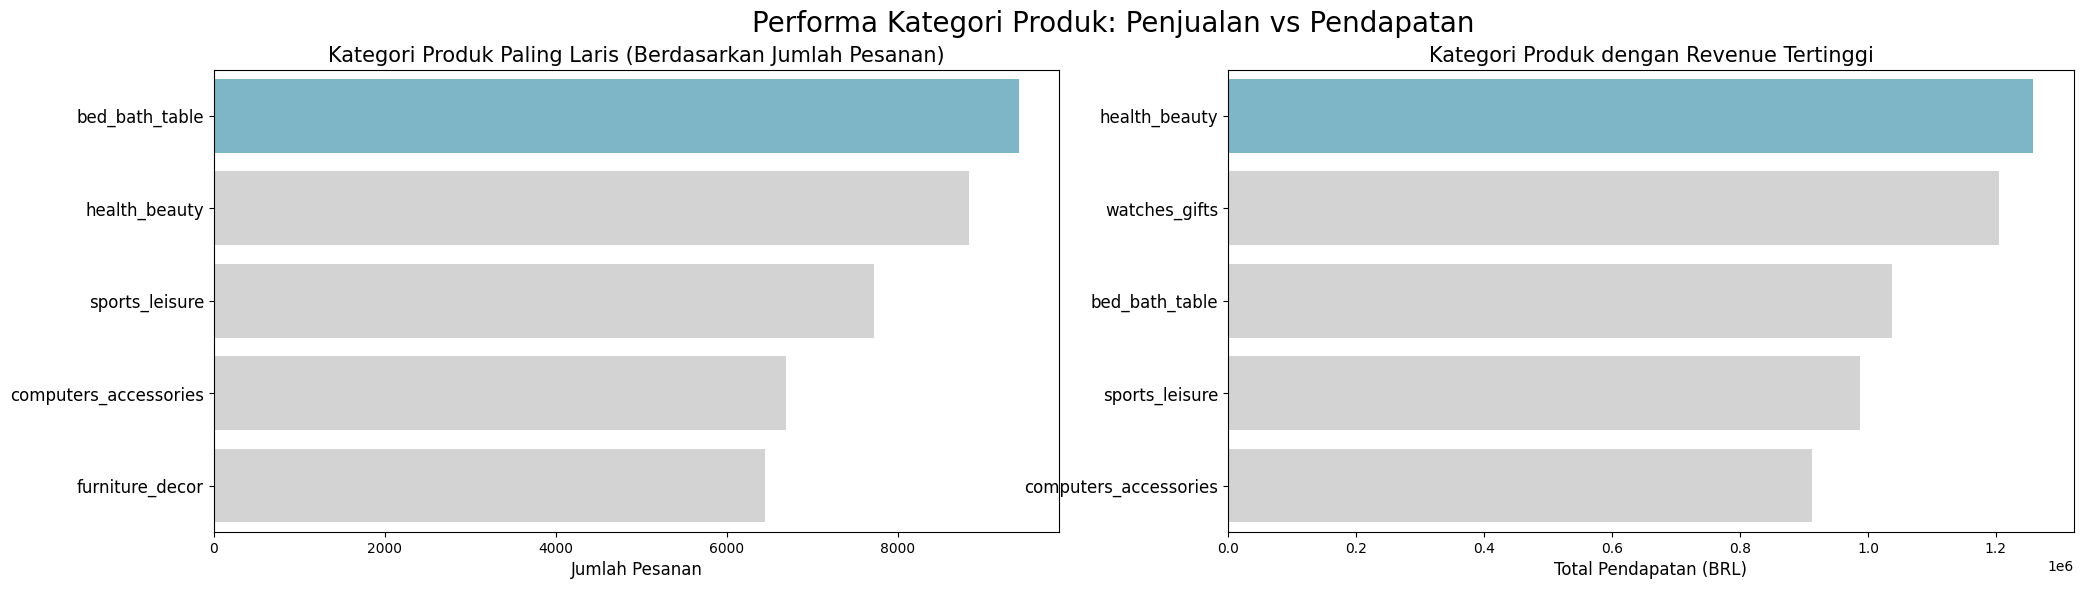

In [15]:
# Menyiapkan data
top_products_sales = all_df.groupby('product_category_name_english').order_id.nunique().sort_values(ascending=False).head(5).reset_index()
top_products_sales.columns = ['Category', 'Total_Orders']

top_products_revenue = all_df.groupby('product_category_name_english').price.sum().sort_values(ascending=False).head(5).reset_index()
top_products_revenue.columns = ['Category', 'Total_Revenue']

# Menyiapkan warna
colors_sales = ["#72BCD4"] + ["#D3D3D3"] * 4
colors_revenue = ["#72BCD4"] + ["#D3D3D3"] * 4

# Membuat layout visualisasi
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

# Grafik 1: Ditambah hue="Category" dan legend=False
sns.barplot(x="Total_Orders", y="Category", hue="Category", data=top_products_sales, palette=colors_sales, ax=ax[0], legend=False)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Jumlah Pesanan", fontsize=12)
ax[0].set_title("Kategori Produk Paling Laris (Berdasarkan Jumlah Pesanan)", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

# Grafik 2: Ditambah hue="Category" dan legend=False
sns.barplot(x="Total_Revenue", y="Category", hue="Category", data=top_products_revenue, palette=colors_revenue, ax=ax[1], legend=False)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Pendapatan (BRL)", fontsize=12)
ax[1].set_title("Kategori Produk dengan Revenue Tertinggi", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Performa Kategori Produk: Penjualan vs Pendapatan", fontsize=20)
plt.show()

### Pertanyaan 2:

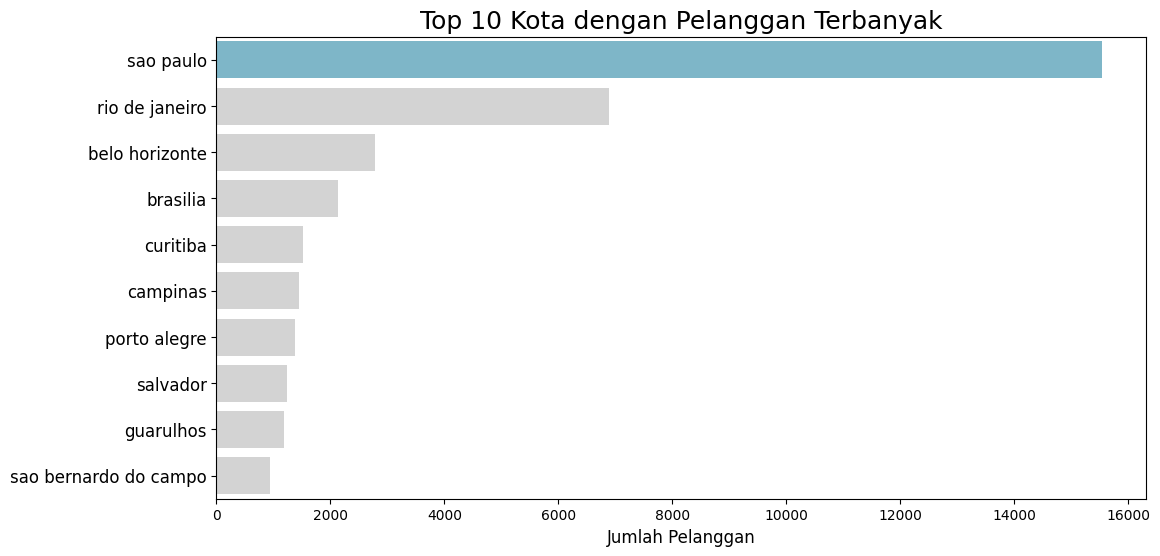

In [16]:
# Menyiapkan data top 10 kota
top_cities = customers_df.groupby('customer_city').customer_id.nunique().sort_values(ascending=False).head(10).reset_index()
top_cities.columns = ['City', 'Total_Customers']

# Menyiapkan visualisasi
plt.figure(figsize=(12, 6))
colors_cities = ["#72BCD4"] + ["#D3D3D3"] * 9

# Ditambah hue="City" dan legend=False
sns.barplot(x="Total_Customers", y="City", hue="City", data=top_cities, palette=colors_cities, legend=False)
plt.title("Top 10 Kota dengan Pelanggan Terbanyak", fontsize=18)
plt.xlabel("Jumlah Pelanggan", fontsize=12)
plt.ylabel(None)
plt.tick_params(axis='y', labelsize=12)
plt.show()

**Insight:**
- Performa Produk: Visualisasi pertama menyoroti perbedaan menarik antara volume dan pendapatan. Meskipun kategori bed_bath_table menduduki peringkat pertama dalam hal frekuensi pesanan terbanyak, kategori health_beauty justru menjadi penyumbang revenue terbesar bagi perusahaan. Hal ini mengindikasikan bahwa produk perawatan kecantikan/kesehatan memiliki margin harga atau nilai transaksi per barang yang lebih tinggi dibandingkan kebutuhan tempat tidur/mandi.

- Demografi Pelanggan: Visualisasi kedua menunjukkan ketimpangan distribusi demografis yang sangat masif. Pelanggan sangat terkonsentrasi di kota Sao Paulo, mengalahkan kota kedua (Rio de Janeiro) dengan selisih lebih dari dua kali lipat. Pemahaman ini sangat vital untuk efisiensi rantai pasok (supply chain) dan penentuan lokasi pusat distribusi gudang di masa depan.

## Analisis Lanjutan (Opsional)

In [ ]:
# ANALISIS LANJUTAN: RFM ANALYSIS
# 1. Menentukan tanggal referensi (1 hari setelah pesanan terakhir di dataset)
recent_date = all_df['order_purchase_timestamp'].max() + pd.DateOffset(days=1)

# 2. Menghitung Recency, Frequency, dan Monetary untuk setiap pelanggan
rfm_df = all_df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (recent_date - x.max()).days, # Recency: Hari sejak pembelian terakhir
    'order_id': 'nunique',                                              # Frequency: Jumlah transaksi
    'price': 'sum'                                                      # Monetary: Total uang yang dihabiskan
}).reset_index()

# 3. Mengganti nama kolom agar lebih mudah dibaca
rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print("--- Top 5 Pelanggan Terbaik Berdasarkan Total Pengeluaran (Monetary) ---")
print(rfm_df.sort_values(by='monetary', ascending=False).head(5))

# MENYIMPAN DATA UNTUK DASHBOARD STREAMLIT
# Pastikan merge dulu dengan customers_df agar punya kolom 'customer_city'
if 'customer_city' not in all_df.columns:
    all_df = pd.merge(
        left=all_df,
        right=customers_df,
        how="left",
        left_on="customer_id",
        right_on="customer_id"
    )

# Memilih kolom yang HANYA dibutuhkan oleh dashboard
main_data = all_df[['order_id', 'customer_id', 'price', 'product_category_name_english', 'customer_city']]

# Menyimpan data yang sudah dipangkas menjadi 'main_data.csv'
main_data.to_csv("dashboard/main_data.csv", index=False)
print("\nData main_data.csv yang ringan berhasil dibuat!")

--- Top 5 Pelanggan Terbaik Berdasarkan Total Pengeluaran (Monetary) ---
                            customer_id  recency  frequency  monetary
8475   1617b1357756262bfa56ab541c47bc16      339          1   13440.0
91284  ec5b2ba62e574342386871631fafd3fc       50          1    7160.0
76948  c6e2731c5b391845f6800c97401a43a9      568          1    6735.0
94398  f48d464a0baaea338cb25f816991ab1f       40          1    6729.0
24603  3fd6777bbce08a352fddd04e4a7cc8f6      467          1    6499.0


KeyError: "['customer_city'] not in index"

## Conclusion

- **Conclution pertanyaan 1:** Berdasarkan analisis performa produk, kategori `bed_bath_table` adalah produk yang paling laris secara kuantitas (volume pesanan tertinggi). Namun, jika dilihat dari segi profitabilitas, kategori `health_beauty` merupakan penyumbang pendapatan (*revenue*) paling besar bagi perusahaan. Strategi bisnis ke depan dapat difokuskan pada promosi silang (*cross-selling*) antara kedua kategori unggulan ini.
- **Conclution pertanyaan 2:** Demografi pelanggan menunjukkan pemusatan yang sangat ekstrem di kota `sao paulo`. Jumlah pelanggan di kota ini mengungguli kota di peringkat kedua (`rio de janeiro`) dengan margin lebih dari dua kali lipat. Perusahaan dapat memanfaatkan *insight* ini untuk mengoptimalkan rute logistik dan menambah pusat distribusi utama di Sao Paulo, sembari merancang kampanye pemasaran khusus untuk melakukan penetrasi pasar di kota-kota lain.